# Pre-Delivery Walkthrough: SCHISM + SFINCS over the Mendocino Coast

End-to-end demo of the `coastal_calibration` library and `nwm_coastal`
QGIS plugin against a single Pacific coastal subdomain (Mendocino /
Point Arena, CA). The walkthrough covers:

1. **Extract** a sub-mesh from the full Pacific SCHISM domain with a
   user polygon and run the SCHISM pipeline.
2. **QGIS** — turn the extracted SCHISM mesh boundary into an SFINCS
   AOI polygon and pick the NWM flowlines that enter the domain.
3. **Build & run** the SFINCS model on the same boundary.
4. **Compare** modeled water levels against a NOAA CO-OPS tide gauge
   in a single 3-line plot (Observed, SCHISM, SFINCS).
5. **Animate** SCHISM and SFINCS water-level fields side-by-side with
   a shared colorbar.

Both simulations are 50 hours long and run locally in roughly 4 minutes
each on this machine; no HPC is required.

## 0. Setup

The walkthrough runs out of `docs/examples/walkthrough/`. The setup
cell below creates that directory and stages every input the
notebook needs:

- **SCHISM mesh + WRF geogrid** — sourced from the cluster paths
  (`/ngen-test/coastal/ngwpc-coastal/parm/...`) when they are
  available, otherwise from the local `docs/examples/pacific/`
  demo. This lets the same notebook run unchanged on the cluster
  and on a workstation.
- **Extract polygon** — the same GeoJSON used by
  `schism-pacific-extract.py` so we carve out the same Mendocino
  subdomain.
- **SFINCS AOI polygon and NWM flowlines** — pre-staged in
  `docs/examples/pacific/` (`sfincs_poly.geojson` and
  `nwm_reaches.geojson`) so the notebook is fully runnable
  end-to-end. Part 2 below documents the QGIS workflow that
  produced them.

In [1]:
from __future__ import annotations

import os
import shutil
from pathlib import Path

notebook_dir = Path.cwd()  # assumes run from docs/examples/notebooks/
walkthrough_dir = (notebook_dir.parent / "walkthrough").resolve()
walkthrough_dir.mkdir(exist_ok=True)
os.chdir(walkthrough_dir)

pacific_dir = (notebook_dir.parent / "pacific").resolve()

# Cluster paths take precedence when present; otherwise fall back to
# the local pacific/ demo's symlinks. This branching keeps a single
# notebook working in both environments without manual edits.
CLUSTER_MODEL = Path("/ngen-test/coastal/ngwpc-coastal/parm/coastal/pacific")
CLUSTER_GEOGRID = Path("/ngen-test/coastal/ngwpc-coastal/parm/domain/geo_em_CONUS.nc")

heavy_inputs: dict[str, Path] = {
    "model": CLUSTER_MODEL if CLUSTER_MODEL.exists() else pacific_dir / "model",
    "geo_em_CONUS.nc": CLUSTER_GEOGRID
    if CLUSTER_GEOGRID.exists()
    else pacific_dir / "geo_em_CONUS.nc",
}
for name, src in heavy_inputs.items():
    dst = walkthrough_dir / name
    if dst.exists() or dst.is_symlink():
        continue
    if not src.exists():
        raise FileNotFoundError(
            f"Required input missing for {name}: tried cluster path "
            f"and {pacific_dir / name}. Provide either the cluster mount or the "
            f"local pacific/ demo setup before running this notebook."
        )
    dst.symlink_to(src.resolve())

# Copy the small lightweight inputs (extract polygon, SFINCS AOI,
# refinement polygon, and NWM flowlines) so the walkthrough directory
# is self-contained.
small_inputs: dict[str, str] = {
    "extract_poly.geojson": "pacific_poly.geojson",
    "aoi.geojson": "sfincs_poly.geojson",
    "refine_poly.geojson": "schism_poly.geojson",
    "discharge_nwm.geojson": "nwm_reaches.geojson",
}
for dst_name, src_name in small_inputs.items():
    src = pacific_dir / src_name
    dst = walkthrough_dir / dst_name
    if dst.exists():
        continue
    if not src.exists():
        raise FileNotFoundError(
            f"{src} is missing. The walkthrough expects pre-staged inputs in "
            f"docs/examples/pacific/ (see Part 2 for the QGIS workflow that "
            f"produced sfincs_poly.geojson and nwm_reaches.geojson)."
        )
    shutil.copyfile(src, dst)

print(f"Working directory: {walkthrough_dir}")
print("Inputs:")
for name in (*heavy_inputs, *small_inputs):
    p = walkthrough_dir / name
    if p.is_symlink():
        kind = f"symlink → {p.resolve()}"
    elif p.is_file():
        kind = f"file ({p.stat().st_size / 1e3:.1f} KB)"
    else:
        kind = "missing"
    print(f"  {name:<28s} {kind}")

Working directory: docs/examples/walkthrough
Inputs:
  model                        symlink → /Volumes/data/schism_models/pacific
  geo_em_CONUS.nc              symlink → /Volumes/data/schism_models/geo_em_CONUS.nc
  extract_poly.geojson         file (0.7 KB)
  aoi.geojson                  file (54.4 KB)
  refine_poly.geojson          file (78.1 KB)
  discharge_nwm.geojson        file (28.8 KB)


## 1. Extract a SCHISM subdomain

`extract_mesh` keeps the portion of the full Pacific SCHISM mesh that
falls inside the polygon and rebuilds the open boundaries where the
polygon edge crosses the mesh. The result is a small, self-contained
project under `extracted/` ready for the pipeline runner.

In [2]:
import shapely

import coastal_calibration.schism.subsetter as ss

poly = shapely.get_geometry(shapely.from_geojson(Path("extract_poly.geojson").read_text()), 0)
print(f"Polygon: {poly.geom_type}, bounds={[round(b, 3) for b in poly.bounds]}")

res = ss.extract_mesh("model", poly, ".", output_name="extracted")
print(
    f"Extracted: {res.classification.n_side_a:,} nodes, {res.subset.side_a.n_elements:,} elements"
)

Polygon: Polygon, bounds=[-123.856, 38.819, -123.616, 39.289]


Extracted: 16,508 nodes, 30,213 elements


### Run the SCHISM pipeline

The runner executes the 12 stages: download, sflux, atmospheric
regridding, boundary conditions, NWM discharge, mesh partitioning,
SCHISM execution, and post-processing (station comparison + obs-points
extraction). On this machine the full 50-hour simulation completes in
roughly 4 minutes.

In [3]:
from coastal_calibration import CoastalCalibConfig, CoastalCalibRunner, configure_logger

configure_logger(level="INFO")

schism_run_dir = walkthrough_dir / "run_schism"

schism_config = CoastalCalibConfig.from_dict(
    {
        "model": "schism",
        "simulation": {
            "start_date": "2025-11-26",
            "duration_hours": 50,
            "coastal_domain": "pacific",
            "meteo_source": "nwm_ana",
            "timestep_seconds": 300,
        },
        "boundary": {"source": "stofs"},
        "paths": {
            "work_dir": str(schism_run_dir),
            "raw_download_dir": "../downloads",
        },
        "download": {"enabled": True},
        "model_config": {
            "prebuilt_dir": "./extracted",
            "geogrid_file": "./geo_em_CONUS.nc",
            "discharge_file": "./extracted/nwmReaches.csv",
            "nodes": 1,
            "ntasks_per_node": 8,
            "nscribes": 2,
            "oversubscribe": True,
            "include_noaa_gages": True,
        },
    }
)

schism_result = CoastalCalibRunner(schism_config).run()
if not schism_result.success:
    raise RuntimeError(
        f"SCHISM pipeline failed at '{schism_result.stages_failed}': {schism_result.errors}"
    )
print(schism_result)

Coastal Calibration Workflow                                                    


Start Time: 2026-04-30 15:11:37                                                 


----------------------------------------                                        


Cleaned generated files from                                                    
docs/examples/walkthrough/run_schism      


Stage: download                                                                 


...

  [✓] schism_prep: 0s                                                           


  [✓] schism_run: 12m 49s                                                       


  [✓] schism_postprocess: 0s                                                    


  [✓] schism_plot: 4s                                                           


WorkflowResult: SUCCESS
  Start:     2026-04-30 15:11:36
  End:       2026-04-30 15:27:46
  Duration:  16m 9s
  Completed: download, schism_forcing_prep, schism_forcing, schism_sflux, schism_params, schism_obs, schism_boundary, schism_discharge, schism_prep, schism_run, schism_postprocess, schism_plot


## 2. QGIS Plugin: derive the SFINCS AOI and discharge points

The SFINCS model needs two inputs that are easiest to produce
interactively in QGIS using the `nwm_coastal` plugin:

1. **`aoi.geojson`** — a polygon that hugs the SCHISM mesh boundary on
   the seaward side and follows the NHF watershed divides on the
   landward side, so the SFINCS domain aligns with hydrologic
   boundaries.
2. **`discharge_nwm.geojson`** — the NWM flowlines that enter the
   domain across that polygon, exported with whatever ID column the
   source NHF dataset uses (typically `"ID"`, `"flowpath_id"`, or
   `"comid"`). The SFINCS create stage takes the column name as a
   config value and normalizes it to `"name"` internally so the run
   stage can look up NWM streamflow by integer feature ID.

**The walkthrough has these files pre-staged** in
`docs/examples/pacific/` (`sfincs_poly.geojson` and
`nwm_reaches.geojson`) so Parts 3–5 are runnable today. The steps
below document how those files were produced.

### Step 1 — Open the extracted SCHISM mesh

In QGIS, click **Load SCHISM Mesh** in the `nwm_coastal` toolbar and
select `extracted/hgrid.gr3` from this walkthrough directory. The
plugin streams it into a temporary 2DM and displays it as a mesh
layer with the bed-elevation dataset attached.

![Load SCHISM mesh](../images/qgis_plugin_window.png)

### Step 2 — Add the basemap

Click **Add Basemap** in the toolbar. Point the dialog at the
National HydroFabric `.gpkg` (or `.gdb`) for this region. The plugin
loads OSM, NHF divides, NWM flowpaths, USGS gages, and (when checked)
auto-downloads NOAA CO-OPS tide gauges as orange stars.

![Add Basemap dialog](../images/qgis_plugin_basemap.png)

### Step 3 — Extract the mesh boundary

With the SCHISM mesh layer selected, click **Extract Mesh Boundary**.
The plugin parses the open / exterior / island boundaries from the
original `hgrid.gr3` and creates a polygon layer that exactly matches
the SCHISM domain.

![Mesh boundary polygon](../images/qgis_plugin_menu.png)

### Step 4 — Union with NHF divides

Click **Draw Polygon** and trace the seaward edge of the AOI roughly
along the mesh boundary; right-click to finish. Then click **Union
with NHF Divides** to snap the landward edge to the watershed divide
polygons that intersect your sketch. This is what makes the SFINCS
domain hydrologically meaningful.

![Sketched AOI polygon](../images/qgis_plugin_poly.png)
![After union with NHF divides](../images/qgis_plugin_merge.png)

### Step 5 — Save the AOI polygon

Click **Save Polygon** and write `aoi.geojson` into this walkthrough
directory. The plugin reprojects to WGS84 on export.

### Step 6 — Pick and export the river discharge flowlines

Use QGIS's selection tool on the `flowpaths` layer to highlight every
NWM flowline that crosses the merged AOI polygon. Click **Export
Selected Flowpaths** and save as `discharge_nwm.geojson` in this
walkthrough directory.

![NWM flowlines into the domain](../images/qgis_plugin_flowlines.png)

The setup cell at the top of this notebook copies the pre-staged
`pacific/sfincs_poly.geojson` to `walkthrough/aoi.geojson` and
`pacific/nwm_reaches.geojson` to `walkthrough/discharge_nwm.geojson`,
so this section can be skipped end-to-end on a re-run. To use a
different domain, regenerate the two GeoJSONs with the steps above
and drop them into `docs/examples/pacific/` under the same names.

## 3. Build & run the SFINCS model

`SfincsCreateConfig.from_dict` bundles every input the model needs:
the AOI polygon, a base 512 m quadtree grid with one refinement level
inside the AOI, NWS 30 m + GEBCO elevation, ESA WorldCover-derived
Manning's *n*, and the QGIS-derived flowlines as discharge sources.
`add_noaa_gages: True` also auto-discovers the same NOAA tide gauge
the SCHISM pipeline uses, which is what makes the 3-line comparison
in Part 4 work without any manual station bookkeeping.

In [4]:
from coastal_calibration import SfincsCreateConfig, SfincsCreator

create_config = SfincsCreateConfig.from_dict(
    {
        "aoi": "./aoi.geojson",
        "output_dir": "./output_sfincs",
        "download_dir": "../downloads/walkthrough_grid",
        "grid": {
            "resolution": 512,
            "crs": "utm",
            "rotated": False,
            # Refine along the coast (SCHISM mesh boundary) rather than
            # the full NHF-union AOI: the coastal corridor is where
            # SFINCS needs higher resolution to keep narrow connections
            # wet across the tidal cycle. Level 4 = 32 m cells.
            "refinement": [
                {"polygon": "./refine_poly.geojson", "level": 4, "buffer_m": -200},
            ],
        },
        "elevation": {
            "datasets": [
                {
                    "name": "nws_30m",
                    "zmin": -20000,
                    "source": "nws_30m",
                    "coastal_domain": "pacific",
                },
                {"name": "gebco_15arcs", "zmin": -20000, "source": "gebco_15arcs"},
            ],
            "buffer_cells": 1,
        },
        "mask": {
            "zmin": -50.0,
            "boundary_zmax": -1.0,
            "reset_bounds": True,
            # Drop tiny isolated active cells just above zmin (offshore
            # bumps that clear the -50 m cutoff but are surrounded by
            # deeper inactive cells) so the model is a single connected
            # domain instead of a few floating fragments.
            "keep_largest_only": True,
        },
        "subgrid": {
            "nr_subgrid_pixels": 4,
            "lulc_dataset": "esa_worldcover",
            "manning_land": 0.04,
            "manning_sea": 0.02,
        },
        "river_discharge": {
            "flowlines": "./discharge_nwm.geojson",
            # `nwm_reaches.geojson` from the QGIS plugin uses "ID" for the
            # NWM feature ID; create.py renames it to "name" internally so
            # the run stage's NWM streamflow lookup works regardless.
            "nwm_id_column": "ID",
        },
        "add_noaa_gages": True,
    }
)

create_result = SfincsCreator(create_config).run()
if not create_result.success:
    raise RuntimeError(
        f"SFINCS create failed at '{create_result.stages_failed}': {create_result.errors}"
    )
print(create_result)

Coastal Calibration Workflow                                                    


Start Time: 2026-04-30 15:27:49                                                 


----------------------------------------                                        


Stage: create_grid                                                              


Start Time: 2026-04-30 15:27:49                                                 


...

  [✓] create_discharge: 0s                                                      


  [✓] create_subgrid: 2m 22s                                                    


  [✓] create_obs: 0s                                                            


  [✓] create_write: 0s                                                          


WorkflowResult: SUCCESS
  Start:     2026-04-30 15:27:49
  End:       2026-04-30 15:30:24
  Duration:  2m 35s
  Completed: create_grid, create_fetch_data, create_elevation, create_mask, create_boundary, create_discharge, create_subgrid, create_obs, create_write


In [5]:
sfincs_run_dir = walkthrough_dir / "run_sfincs"

sfincs_run_config = CoastalCalibConfig.from_dict(
    {
        "model": "sfincs",
        "simulation": {
            "start_date": "2025-11-26",
            "duration_hours": 50,
            "coastal_domain": "pacific",
            "meteo_source": "nwm_ana",
        },
        "boundary": {"source": "stofs"},
        "paths": {
            "work_dir": str(sfincs_run_dir),
            "raw_download_dir": "../downloads",
        },
        "download": {"enabled": True},
        "model_config": {
            "prebuilt_dir": "./output_sfincs",
            "discharge_locations_file": "./output_sfincs/sfincs_nwm.src",
            "merge_discharge": True,
            "forcing_to_mesh_offset_m": 0.0,
            # NAVD88→LMSL offset for Mendocino (~39N, -123.7W) from NOAA VDatum.
            # Verify / re-derive for other domains via:
            # https://vdatum.noaa.gov/vdatumweb/api/convert?s_x=<lon>&s_y=<lat>&s_z=0&region=westcoast&s_h_frame=NAD83_2011&s_v_frame=NAVD88&t_h_frame=IGS14&t_v_frame=LMSL
            "vdatum_mesh_to_msl_m": -0.92,
            "include_precip": True,
            "include_wind": True,
            "include_pressure": True,
            "floodmap_dem": "../downloads/walkthrough_grid/nws_30m.tif",
            # Stability settings tuned for tidal + compound flooding on a
            # finely refined coastal mesh. ``advection=0`` is the
            # standard SFINCS choice for tide-dominated runs (advection
            # destabilises shallow water at low tide on quadtree
            # transitions); a small constant viscosity damps residual
            # high-frequency noise. Same family of settings as the
            # Lavaca demo (``docs/examples/notebooks/lavaca.py``).
            "inp_overrides": {
                "tspinup": 10800,
                "advection": 0,
                "viscosity": 0,
                "nuvisc": 0.01,
            },
        },
    }
)

sfincs_result = CoastalCalibRunner(sfincs_run_config).run()
if not sfincs_result.success:
    raise RuntimeError(
        f"SFINCS pipeline failed at '{sfincs_result.stages_failed}': {sfincs_result.errors}"
    )
print(sfincs_result)

Coastal Calibration Workflow                                                    


Start Time: 2026-04-30 15:30:24                                                 


----------------------------------------                                        


Cleaned generated files from                                                    
docs/examples/walkthrough/run_sfincs      


Stage: download                                                                 


...

  [✓] sfincs_write: 0s                                                          


  [✓] sfincs_run: 1h 0m 1s                                                      


  [✓] sfincs_floodmap: 1s                                                       


  [✓] sfincs_plot: 2s                                                           


WorkflowResult: SUCCESS
  Start:     2026-04-30 15:30:24
  End:       2026-04-30 16:31:14
  Duration:  1h 0m 49s
  Completed: download, sfincs_symlinks, sfincs_data_catalog, sfincs_init, sfincs_timing, sfincs_forcing, sfincs_discharge, sfincs_precip, sfincs_wind, sfincs_pressure, sfincs_write, sfincs_run, sfincs_floodmap, sfincs_plot


## 4. Compare water levels at the NOAA gauge

Each pipeline writes `obs_water_level.parquet` to its run directory —
a station × time table of modeled water levels at every observation
point picked up during post-processing (in this domain, just the one
CO-OPS gauge that lies inside both meshes). Combined with a fresh
`query_coops_byids` call for the matching observed series, we feed
both runs into `plot_station_comparison` and get a single figure with
**Observed**, **SCHISM**, and **SFINCS** lines per station.

In [6]:
from datetime import timedelta

import pandas as pd

from coastal_calibration.data.coops_api import COOPSAPIClient, query_coops_byids
from coastal_calibration.plotting import plot_station_comparison

schism_obs_parquet = schism_run_dir / "obs_water_level.parquet"
sfincs_obs_parquet = sfincs_run_dir / "sfincs_model" / "obs_water_level.parquet"

schism_series = pd.read_parquet(schism_obs_parquet)
sfincs_series = pd.read_parquet(sfincs_obs_parquet)
print(f"SCHISM obs columns: {list(schism_series.columns)}")
print(f"SFINCS obs columns: {list(sfincs_series.columns)}")

# Keep only the CO-OPS station IDs (numeric 7-digit codes).
common_stations = sorted(set(schism_series.columns) & set(sfincs_series.columns))
station_ids = [s for s in common_stations if s.isdigit() and len(s) == 7]
if not station_ids:
    raise RuntimeError(
        "No NOAA CO-OPS station appears in both runs' obs_water_level.parquet — "
        "check that `add_noaa_gages` (SFINCS) and `include_noaa_gages` (SCHISM) "
        "both selected at least one gauge in the domain."
    )
print(f"Comparison stations: {station_ids}")

# Re-fetch CO-OPS observations for the simulation window and convert to MSL.
sim = schism_config.simulation
begin_date = sim.start_date.strftime("%Y%m%d %H:%M")
end_dt = sim.start_date + timedelta(hours=sim.duration_hours)
end_date = end_dt.strftime("%Y%m%d %H:%M")

obs_ds = query_coops_byids(
    station_ids,
    begin_date,
    end_date,
    product="water_level",
    datum="MLLW",
    units="metric",
    time_zone="gmt",
)

datums = COOPSAPIClient().get_datums(station_ids)
datum_map = {d.station_id: d for d in datums}
for sid in station_ids:
    d = datum_map.get(sid)
    if d is None:
        continue
    msl = d.get_datum_value("MSL")
    mllw = d.get_datum_value("MLLW")
    if msl is None or mllw is None:
        continue
    offset = msl - mllw
    if d.units == "feet":
        offset *= 0.3048
    obs_ds.water_level.loc[{"station": sid}] -= offset
obs_ds.attrs["datum"] = "MSL"

# Build (times, elevation[n_t, n_stations]) tuples in the column order of station_ids.
schism_pair = (
    schism_series.index.to_numpy(),
    schism_series[station_ids].to_numpy(),
)
sfincs_pair = (
    sfincs_series.index.to_numpy(),
    sfincs_series[station_ids].to_numpy(),
)

walkthrough_figs = walkthrough_dir / "figs"
walkthrough_figs.mkdir(exist_ok=True)
combined_paths = plot_station_comparison(
    {"SCHISM": schism_pair, "SFINCS": sfincs_pair},
    station_ids,
    walkthrough_figs,
    obs_ds=obs_ds,
)
print(f"Wrote {len(combined_paths)} comparison figure(s) to {walkthrough_figs}")

  Loading cached station metadata from cache/coops_stations_metadata.json       


  Requesting water_level data for 1 station(s) from 20251126 00:00 to 20251128  
02:00                                                                           


  Fetching data from 1 station(s)                                               


SCHISM obs columns: ['9416841']
SFINCS obs columns: ['9416841']
Comparison stations: ['9416841']


  Successfully retrieved data for 1 station(s)                                  


  Loading cached station metadata from cache/coops_stations_metadata.json       


  Fetching datum information for 1 station(s)                                   


  Fetching data from 1 station(s)                                               


Wrote 1 comparison figure(s) to docs/examples/walkthrough/figs


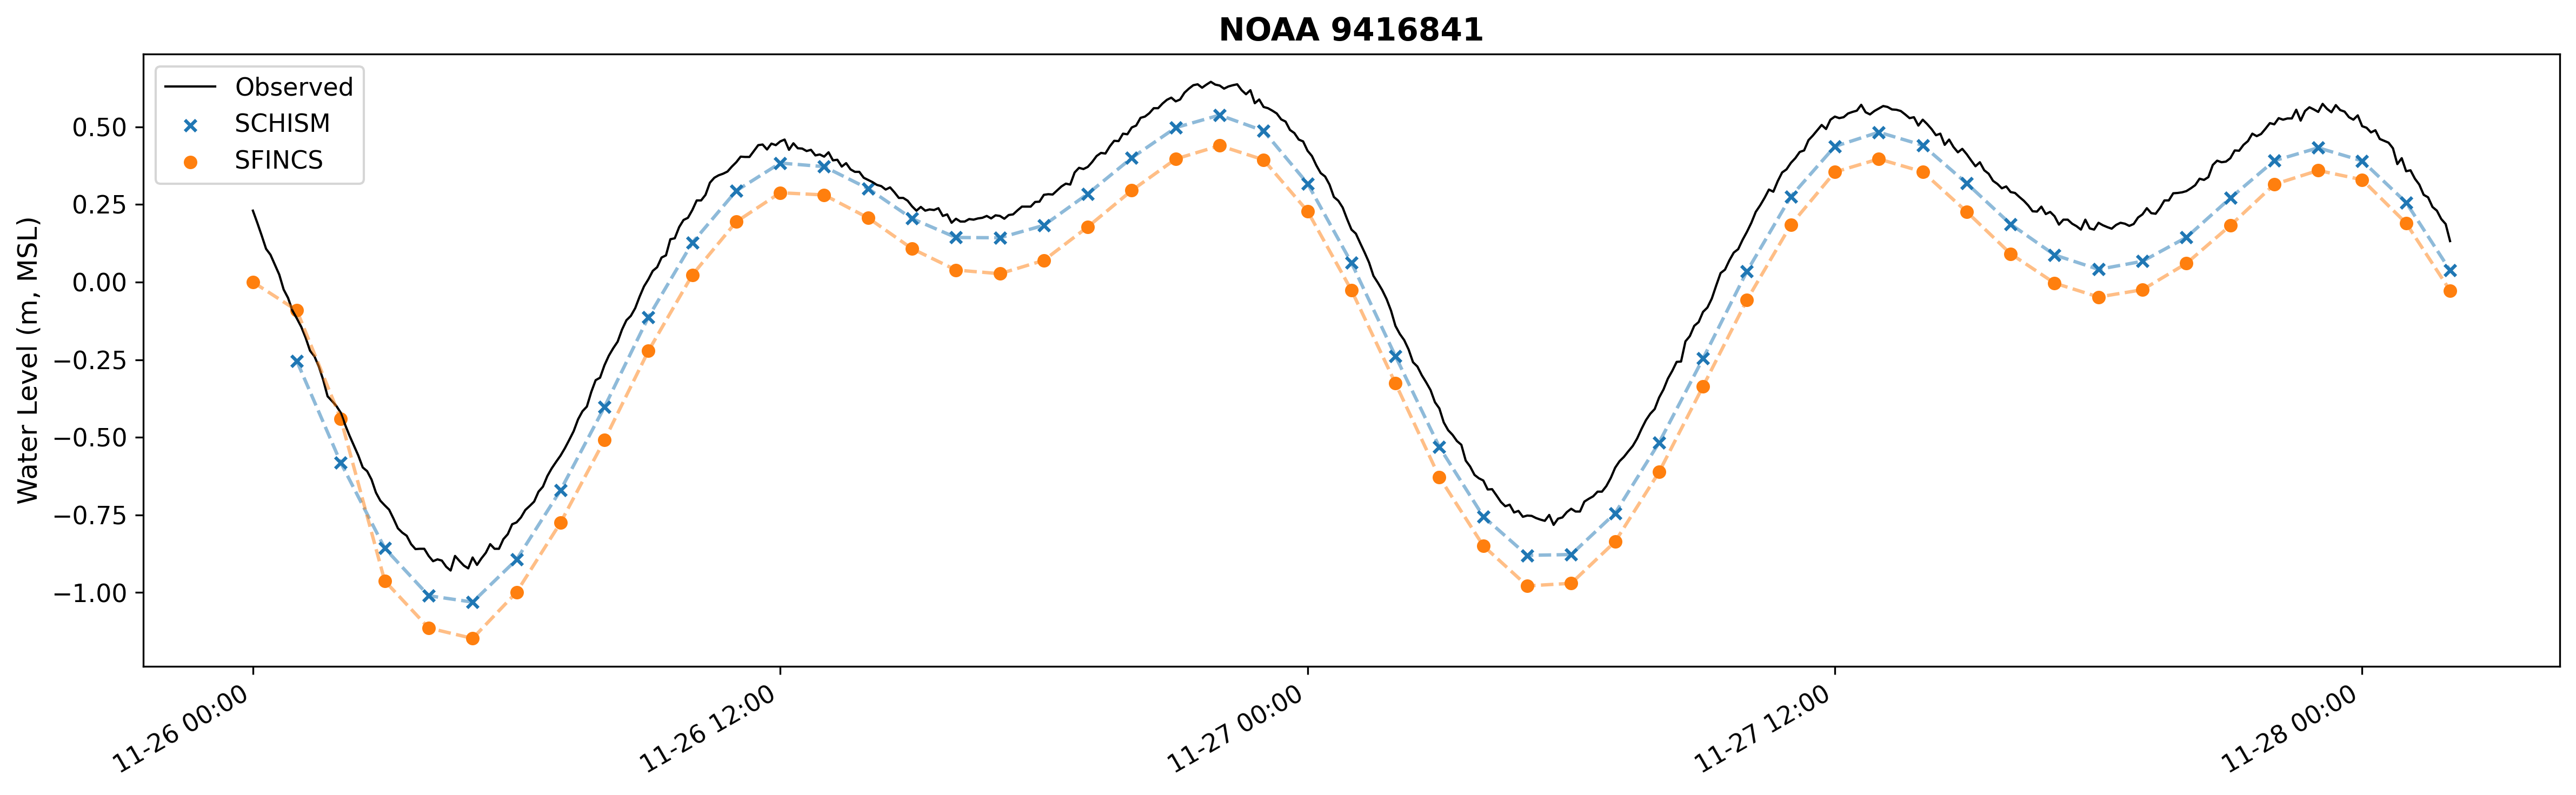

In [7]:
from IPython.display import Image, display

for png in combined_paths:
    display(Image(filename=str(png), width=900))

## 5. Side-by-side spatial animation

`animate_water_level_comparison` renders two panels driven by their
own datasets but locked to a shared colormap range and synchronised on
a common time clock. The two models output at different cadences
(SCHISM hourly, SFINCS half-hourly) — the function takes the
intersection of their time coverage, picks the coarser axis as the
master clock, and uses nearest-neighbour lookup to populate the other
panel each frame.

### A note on the river channels

Both models show water at the upstream NWM inflow points but not
along the river course down to the ocean. This is not a bug — it is
a property of the **NWS 30 m topobathy DEM**, which captures coastal
bathymetry but does not carve river channels into the inland part of
the grid. The model bed along the rivers therefore sits at the
surrounding land elevation (tens of metres above MSL), so river
discharge from `nwm_reaches.geojson` deposits water on a "high"
bed: a small puddle forms at the inflow point but cannot flow
downhill over a bed that is already above the water surface.

Tightening the visualization's wet-cell threshold from 0.05 m to
0.0 m exposes the thin film of water that does propagate, but the
rest of the river course genuinely has `h ≤ 0` in the model output.
A proper fix needs a hydro-conditioned DEM (rivers burned into the
topobathy) — that is intentionally **out of scope** for this demo.

In [8]:
from coastal_calibration.plotting import animate_water_level_comparison
from coastal_calibration.schism.outputs import load_schism_elevation
from coastal_calibration.sfincs.outputs import load_sfincs_water_level

schism_ds = load_schism_elevation(
    schism_run_dir,
    correction_file=walkthrough_dir / "extracted" / "elevation_correction.csv",
)
sfincs_ds = load_sfincs_water_level(sfincs_run_dir / "sfincs_model")
print(f"SCHISM: {dict(schism_ds.sizes)}, mesh_type={schism_ds.attrs['mesh_type']}")
print(f"SFINCS: {dict(sfincs_ds.sizes)}, mesh_type={sfincs_ds.attrs['mesh_type']}")

SCHISM: {'time': 50, 'node': 16508, 'face': 30213, 'face_node': 4}, mesh_type=ugrid-triangle-or-quad
SFINCS: {'time': 51, 'face': 124595, 'node': 498380, 'face_node': 4}, mesh_type=ugrid-quadtree


In [9]:
from IPython.display import Video

side_by_side = animate_water_level_comparison(
    schism_ds,
    sfincs_ds,
    walkthrough_figs / "schism_vs_sfincs.mp4",
    labels=("SCHISM", "SFINCS"),
    fps=8,
    time_stride=2,
    cmap="viridis",
    figsize=(16, 7),
    title_prefix="Mendocino — water-level comparison",
    # Lower the wet-cell threshold so the thin film of water near
    # the river inflows is visible (see the note above on rivers).
    dry_threshold=0.0,
)
print(f"Wrote {side_by_side.name}  ({side_by_side.stat().st_size / 1024:.0f} KB)")

Video(str(side_by_side), embed=True, width=900)

wrote                                                                           
docs/examples/walkthrough/figs/schism_vs_s
fincs.mp4 (25 frames, 8 fps, master=left)                                       


Wrote schism_vs_sfincs.mp4  (235 KB)


## Summary

The walkthrough exercised the full client-facing surface of the
library plus the QGIS plugin:

- **Subdomain extraction** — `extract_mesh` carved a Mendocino
  subdomain from the 3.1 M-node Pacific mesh in seconds.
- **Unified pipeline runner** — the same `CoastalCalibRunner` ran a
  12-stage SCHISM job and, with a different config, a 14-stage SFINCS
  job on the matching domain.
- **QGIS plugin** — the plugin's *Load SCHISM Mesh*, *Extract Mesh
  Boundary*, *Union with NHF Divides*, and *Export Selected Flowpaths*
  actions chained the SCHISM mesh boundary into a hydrologically
  meaningful SFINCS AOI and a discharge-flowline geojson.
- **3-line comparison** — `plot_station_comparison` overlaid Observed,
  SCHISM, and SFINCS series at the shared CO-OPS gauge.
- **Side-by-side animation** — the new
  `animate_water_level_comparison` rendered the two model fields with
  a single shared colorbar, handling the two different output cadences
  automatically.